# The Robert and Rosenbaum Uncertainty Zones model

## Implementation by 
## Marcos Costa Santos Carreira
## École Polytechnique - CMAP
## Dec-2019

## Import packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from functools import partial
import scipy.stats as st
from scipy.special import kv
import seaborn as sns
from scipy import optimize

In [2]:
# import ruptures as rpt

In [3]:
import datetime as dtt
import timeit

In [4]:
import uz as uz

In [5]:
#import cProfile
# useful to check bottlenecks
# But the biggest improvement is to parallelize \
#     the Monte Carlo simulations

In [6]:
pd.set_option('display.max_rows', 80)
pd.set_option('display.max_columns', 80)

## File paths

In [7]:
# pathdata='/Users/marcoscscarreira/Documents/X/CME project/data/'
# pathdfs='/Users/marcoscscarreira/Documents/X/CME project/dfs/'
pathdfs='/Users/marcoscscarreira/My Papers/UZModelUncertainty/dfs/'
# useful to store the raw paths, the processed paths and the statistics

## Simulations

### Parameters

In [8]:
# npaths = 50 # should be enough?
# npaths = 2
# Spot = 100.
# tm = 1. # one trading day
# dt = 0.005 # step 0.005s=5ms
# hours = 8 # a trading day for stocks
# dtosec = np.sqrt(hours*3600)
# nrsteps = int(np.round((dtosec**2)/dt))
# tmrst = uz.atrange(nrsteps,tm)

In [9]:
npaths = 1
s = 100.
tm = 1. # one trading day
hours = 9

In [10]:
nrsteps = 2**25 # 2**25

In [11]:
hours * 3600 / nrsteps

0.0009655952453613281

In [12]:
dt = hours * 3600 / nrsteps # step 0.000965s=1ms
dtosec = np.sqrt(hours*3600)
tmrst = uz.atrange(nrsteps, tm)

tmrstsec = tmrst * hours * 3600

In [13]:
# vollist   = [0.00125, 0.0025, 0.005, 0.01, 0.02] # For the trading hours
# alphalist = [0.005, 0.01, 0.02, 0.04]
# etalist   = [0.0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
# mulist = [-0.03, -0.02, -0.01, -0.005, 0.0, +0.005, +0.01, +0.02, +0.03]
# spotlist = [97., 98., 99., 99.5, 99.75, 100., 100.25, 100.5, 101., 102., 103.]

The durations can be estimated by the formula:

$2\cdot\eta\cdot\left(\frac{\alpha}{S}\cdot\frac{1}{\sigma}\right)^{2}$

In [14]:
# durlist = np.array([[v, a, e, uz.dur(Spot, a, e, v)] \
#                        for e in etalist \
#                        for a in alphalist \
#                        for v in vollist])

In [15]:
# durdf=pd.DataFrame(durlist,columns=['vol','alpha','eta','dur'])
# durdf['dursec']=durdf['dur']*dtosec**2

We want to make sure our simulation has steps small enough to capture
the durations for $\eta$=0.1

In [16]:
# durdf[durdf['eta']==0.1].set_index(['vol','alpha','eta']).sort_index()

In [17]:
# durdf.set_index(['vol','alpha','eta']).sort_index()

### Raw paths - Generation

In [18]:
seed = 42

In [19]:
rndns = uz.frndn(nrsteps, seed)

In [20]:
σ = 0.01
μ = 0.
σ2 = 0.015
μ2 = 0.05
σ3 = 0.005
μ3 = 0.0004*(9*60)  # 0.216
v = np.full(nrsteps, σ)
mu = np.full(nrsteps, μ)
v1 = np.concatenate((np.full(nrsteps//16, σ), np.full(nrsteps//16 * 15, σ2)))
mu1 = np.concatenate((np.full(nrsteps//16, μ), np.full(nrsteps//16 * 15, μ2)))
v2 = np.concatenate((np.full(nrsteps//16, σ), np.full(nrsteps//16 * 15, σ3)))
mu2 = np.concatenate((np.full(nrsteps//16, μ), np.full(nrsteps//16 * 15, μ3)))

In [21]:
# pd.Series(v, index=tmrst[:-1]).plot(figsize=(9, 6), color='k');
# pd.Series(v1, index=tmrst[:-1]).plot(figsize=(9, 6), color='g');
# pd.Series(v2, index=tmrst[:-1]).plot(figsize=(9, 6), color='b');

In [22]:
# pd.Series(mu, index=tmrst[:-1]).plot(figsize=(9, 6), color='k');
# pd.Series(mu1, index=tmrst[:-1]).plot(figsize=(9, 6), color='g');
# pd.Series(mu2, index=tmrst[:-1]).plot(figsize=(9, 6), color='b');

In [23]:
# tmrst = uz.atrange(nrsteps, tm)
# tmrst = uz.atrange(nrsteps, tm)

In [24]:
path0 = uz.MCPath(rndns, v, s, tm, mu)  # Black, trend μ vol σ
path1 = uz.MCPath(rndns, v1, s, tm, mu)  # Green, vol from σ to σ2
path2 = uz.MCPath(rndns, v, s, tm, mu1)  # Blue, trend from μ to μ2
path3 = uz.MCPath(rndns, v, s, tm, mu)  # Magenta, trend μ vol σ but η changes
path4 = uz.MCPath(rndns, v, s, tm, mu2)  # Red, burst
path5 = uz.MCPath(rndns, v2, s, tm, mu2)  # Yellow, burst with low vol
path6 = uz.MCPath(rndns, v, s, tm, mu)  # ?, trend μ vol σ but α changes

In [116]:
path7 = uz.MCPath(rndns, v2, s, tm, mu)  # ?, vol from σ to σ2

In [25]:
# pd.Series(path0, index=tmrst).plot(figsize=(9, 6), color='k');
# pd.Series(path1, index=tmrst).plot(figsize=(9, 6), color='g');
# pd.Series(path2, index=tmrst).plot(figsize=(9, 6), color='b');
# pd.Series(path3, index=tmrst).plot(figsize=(9, 6), color='m');
# pd.Series(path4, index=tmrst).plot(figsize=(9, 6), color='r');
# pd.Series(path5, index=tmrst).plot(figsize=(9, 6), color='y');

In [26]:

# signal = np.transpose(np.array([path0, path1, path2, path3]))

In [27]:

# algo = rpt.Pelt(model='l2', min_size=100).fit(signal)
# my_bkps = algo.predict(pen=10)

In [28]:

# rpt.display(signal, my_bkps)

In [29]:
α = 0.01
α2 = 0.005
η = 0.35
η2 = 0.15
alpha = np.full(nrsteps, α)
alpha1 = np.concatenate((np.full(nrsteps//16, α), np.full(nrsteps//16 * 15, α2)))
eta = np.full(nrsteps, η)
eta1 = np.concatenate((np.full(nrsteps//16, η), np.full(nrsteps//16 * 15, η2)))

In [30]:
trpath0 = uz.trprpath(α, η, path0)
trpath1 = uz.trprpath(α, η, path1)
trpath2 = uz.trprpath(α, η, path2)
trpath3 = uz.trprpathk(alpha, eta1, path3)
trpath4 = uz.trprpath(α, η, path4)
trpath5 = uz.trprpath(α, η, path5)
trpath6 = uz.trprpathk(alpha1, eta, path6)

In [117]:
trpath7 = uz.trprpath(α, η, path7)

In [31]:
# pd.Series(trpath0, index=tmrst).loc[:0.10].plot(figsize=(9, 6), color='k');
# pd.Series(trpath1, index=tmrst).loc[:0.10].plot(figsize=(9, 6), color='g');
# pd.Series(trpath2, index=tmrst).loc[:0.10].plot(figsize=(9, 6), color='b');
# pd.Series(trpath3, index=tmrst).loc[:0.10].plot(figsize=(9, 6), color='m');
# pd.Series(trpath4, index=tmrst).loc[:0.10].plot(figsize=(9, 6), color='r');
# pd.Series(trpath5, index=tmrst).loc[:0.10].plot(figsize=(9, 6), color='y');

In [32]:

# signal_tr = np.transpose(np.array([trpath0, trpath1, trpath2, trpath3]))

In [33]:

# algo_tr = rpt.Pelt(model='l2', min_size=100).fit(signal_tr)
# my_bkps_tr = algo_tr.predict(pen=3)

In [34]:

# rpt.display(signal_tr, my_bkps_tr)

In [35]:
pxchg0 = uz.diff_prices_df_nogroup(pd.Series(trpath0, index=tmrstsec), α)
pxchg1 = uz.diff_prices_df_nogroup(pd.Series(trpath1, index=tmrstsec), α)
pxchg2 = uz.diff_prices_df_nogroup(pd.Series(trpath2, index=tmrstsec), α)
pxchg3 = uz.diff_prices_df_nogroup(pd.Series(trpath3, index=tmrstsec), α)
pxchg4 = uz.diff_prices_df_nogroup(pd.Series(trpath4, index=tmrstsec), α)
pxchg5 = uz.diff_prices_df_nogroup(pd.Series(trpath5, index=tmrstsec), α)
# pxchg6 = uz.diff_prices_df_nogroup(pd.Series(trpath6, index=tmrstsec), α)

In [118]:
pxchg7 = uz.diff_prices_df_nogroup(pd.Series(trpath7, index=tmrstsec), α)

In [36]:
len(pxchg0)

13833

In [37]:
# ηrng = np.concatenate((np.arange(0.05, 0.60 + 0.01, 0.01),
#                        np.array([0.70, 0.80, 1.0, 1.5, 2.0])))

In [38]:
ηrng = np.concatenate((np.arange(0.05, 0.55 + 0.01, 0.01),
                       np.array([0.60, 0.70, 0.80, 1.0, 1.5, 2.0])))

In [39]:
σrng = np.concatenate((np.arange(0.002, 0.020 + 0.0005, 0.0005),
                       np.array([0.025, 0.030, 0.040, 0.050])))  # , 0.075, 0.100

In [40]:
μrng = np.arange(-1.00, +1.00 + 0.02, 0.02)  # 0.02 step

In [41]:
def prior_lognorm(param_rng, shape, loc, scale):
    prior_vals = np.array([st.lognorm.pdf(x, shape, loc, scale) for x in param_rng])
    return prior_vals / np.sum(prior_vals)

In [42]:
def prior_norm(param_rng, loc, scale):
    prior_vals = np.array([st.norm.pdf(x, loc, scale) for x in param_rng])
    return prior_vals / np.sum(prior_vals)

In [43]:
def prior_uniform(param_rng):
    prior_vals = np.array([1 for x in param_rng])
    return prior_vals / np.sum(prior_vals)

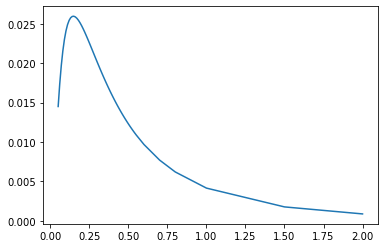

In [44]:
pd.Series(prior_lognorm(ηrng, 1, 0, 0.4), index=ηrng).plot();

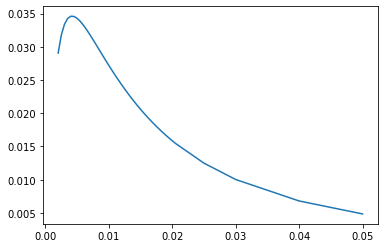

In [45]:
pd.Series(prior_lognorm(σrng, 1.25, 0, 0.02), index=σrng).plot();

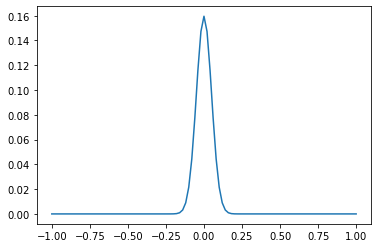

In [46]:
pd.Series(prior_norm(μrng, 0, 0.05), index=μrng).plot();

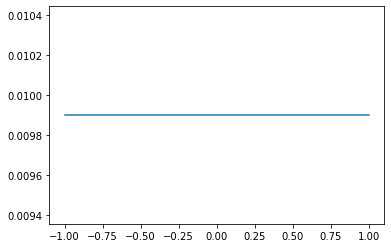

In [47]:
pd.Series(prior_uniform(μrng), index=μrng).plot();

In [48]:
η0 = prior_lognorm(ηrng, 1, 0, 0.4)
σ0 = prior_lognorm(σrng, 1.25, 0, 0.02)
# μ0 = prior_norm(μrng, 0, 0.05)
μ0 = prior_uniform(μrng)

In [49]:
ηs = {ηrng[j]: η0[j] for j in range(len(ηrng))}
σs = {σrng[j]: σ0[j] for j in range(len(σrng))}
μs = {μrng[j]: μ0[j] for j in range(len(μrng))}

### Conversion

int(sign) -> ud

int(Al * 1) -> al

int(Li) -> k

Ptj -> s

α -> α

dtj / (hours * 3600) -> t

In [50]:
# test_list = []
# for j in range(len(test)):
#     row = test.iloc[j]
#     if pd.isna(row['sign']):
#         ud = 0
#     else:
#         ud = int(row['sign'])
#     al = int(row['Al'])
#     if pd.isna(row['Li']):
#         k = 0
#     else:
#         k = int(row['Li'])
#     s = row['Ptj']
#     α = α
#     t = row['dtj'] / (hours * 3600)
#     new_row = [[ud, al, k, s, α, t]]
#     test_list = test_list + new_row

In [51]:
def df_to_list(df):
    df_list = []
    for j in range(len(df)):
        row = df.iloc[j]
        if pd.isna(row['sign']):
            ud = 0
        else:
            ud = int(row['sign'])
        al = int(row['Al'])
        if pd.isna(row['Li']):
            k = 0
        else:
            k = int(row['Li'])
        s = row['Ptj']
        t = row['dtj'] / (hours * 3600)
        new_row = [[ud, al, k, s, α, t]]
        df_list = df_list + new_row
    return df_list

In [52]:
pxchg0list = df_to_list(pxchg0.loc[:0.15 * hours * 3600])

In [53]:
len(pxchg0list)

2057

In [54]:
proc0 = uz.Process(ηs, σs, μs, roll_window=20, update_freq=20)

In [146]:
proc0b = uz.Process(ηs, σs, μs, roll_window=20, update_freq=20)

In [55]:
proc0.init_px(pxchg0list[0])

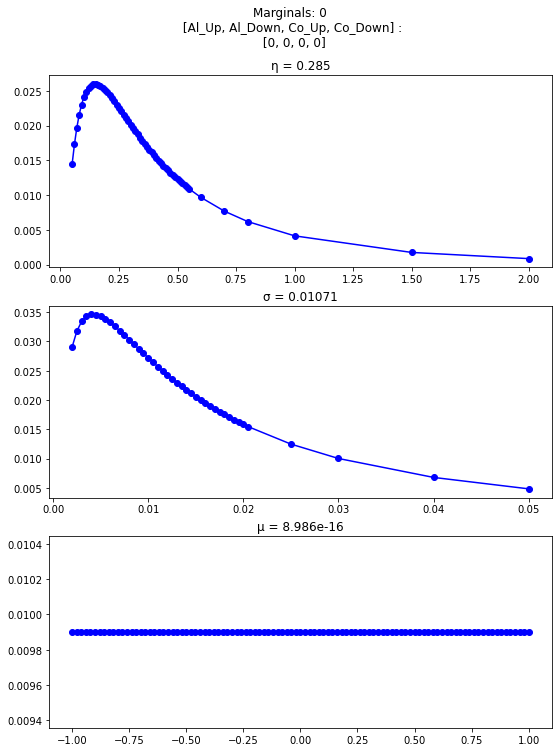

In [147]:
proc0b.plot_marginals

In [57]:
print('start')
currentDT1 = dtt.datetime.now()
print (str(currentDT1))

proc0.init_px_chg(pxchg0list[1])

print('end')
currentDT2 = dtt.datetime.now()
print (str(currentDT2))

print (str(currentDT2 - currentDT1))

start
2020-10-31 15:03:30.339134
end
2020-10-31 15:03:35.890875
0:00:05.551741


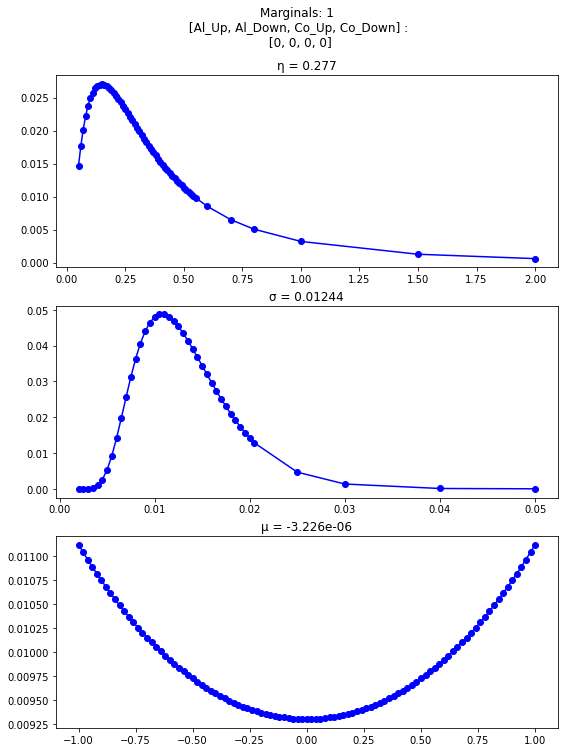

In [58]:
proc0.plot_marginals

In [59]:
print('start')
currentDT1 = dtt.datetime.now()
print (str(currentDT1))

proc0.update_with_counts(pxchg0list[2])

print('end')
currentDT2 = dtt.datetime.now()
print (str(currentDT2))

print (str(currentDT2 - currentDT1))

start
2020-10-31 15:03:36.491939
end
2020-10-31 15:03:41.661988
0:00:05.170049


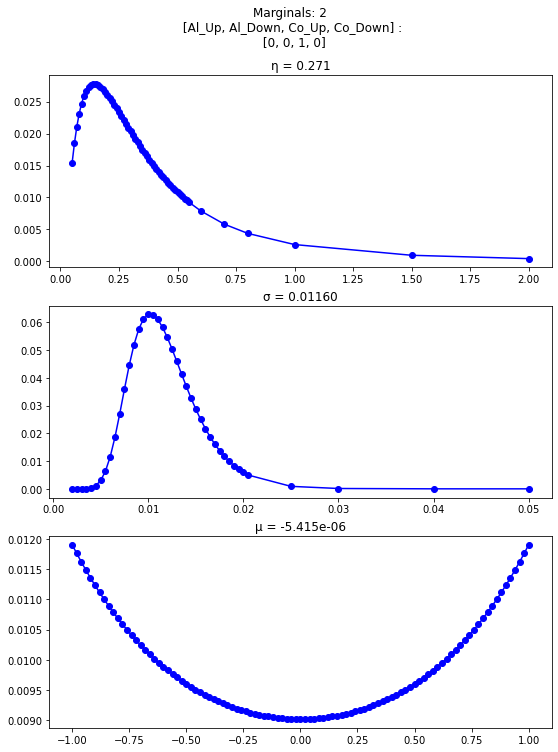

In [60]:
proc0.plot_marginals

In [61]:
uz.multinom_likel(np.array([0.3, 0.3, 0.2, 0.2]), np.array([7, 7, 3, 3]))

0.008144015344717816

In [62]:
proc0.calc_update_freq()

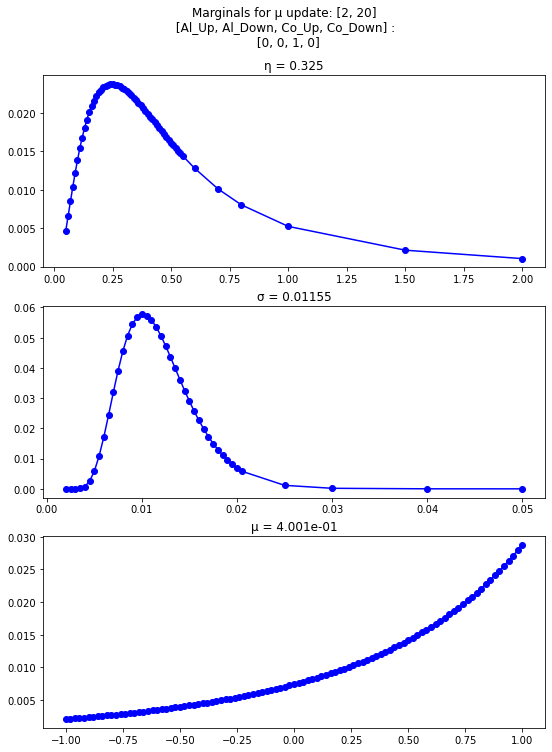

In [63]:
proc0.plot_marginals_μ

In [64]:
for j in range(3, 21):
    proc0.update_with_counts(pxchg0list[j])
#     proc.update(*test_list[j])
    print(j)

3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20


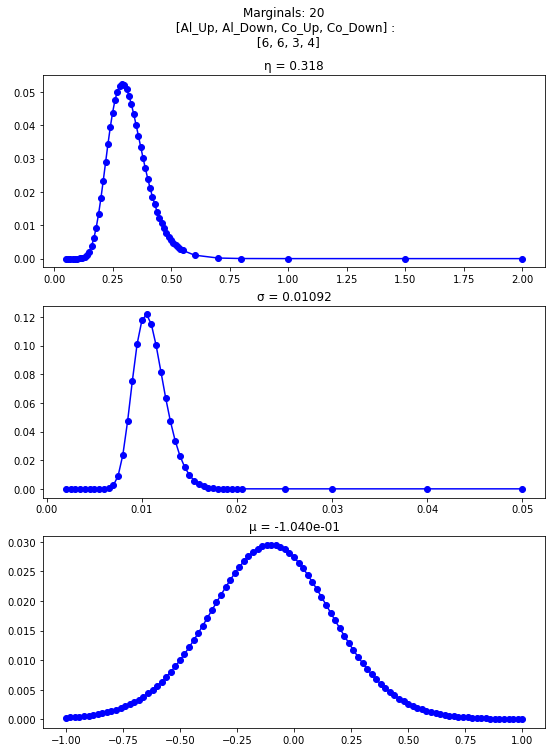

In [65]:
proc0.plot_marginals

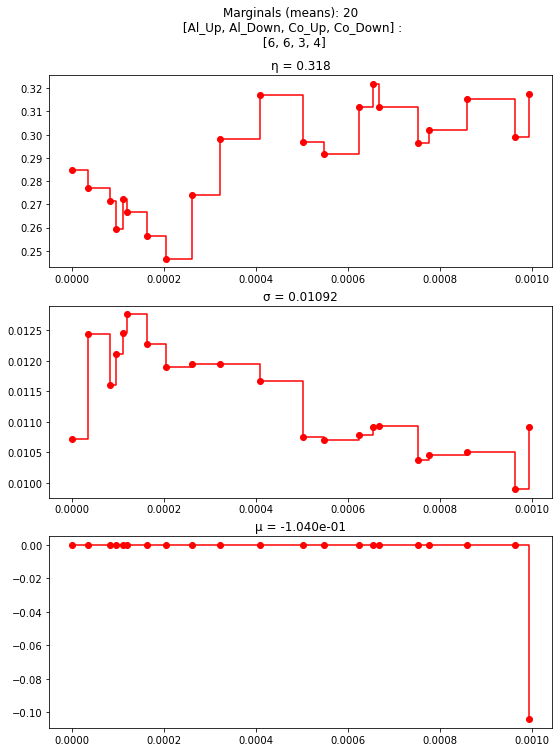

In [66]:
proc0.plot_marginals_means

In [67]:
for j in range(21, 51):
    proc0.update_with_counts(pxchg0list[j])
#     proc.update(*test_list[j])
    if j % 10 == 0:
        print(j)

30
40
50


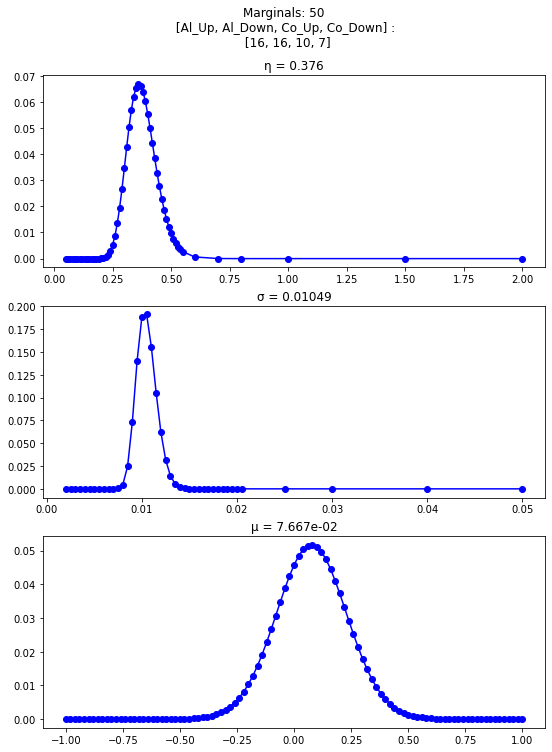

In [68]:
proc0.plot_marginals

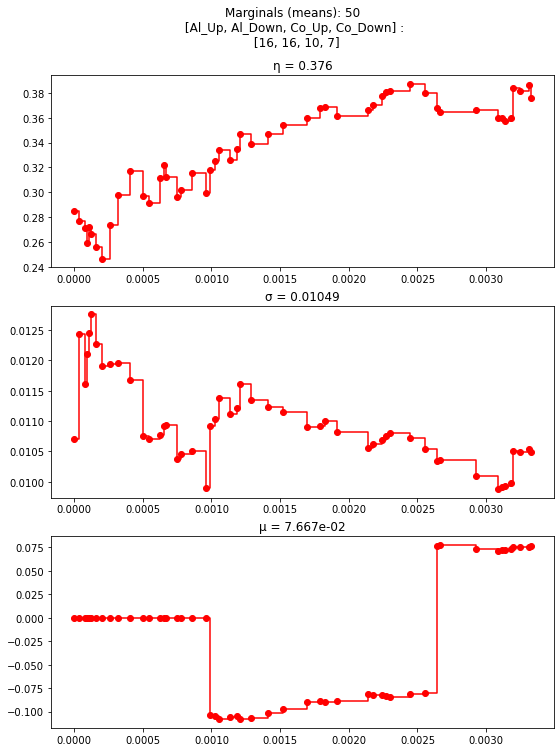

In [69]:
proc0.plot_marginals_means

In [70]:
for j in range(51, 101):
    proc0.update_with_counts(pxchg0list[j])
#     proc.update(*test_list[j])
    if j % 10 == 0:
        print(j)

60
70
80
90
100


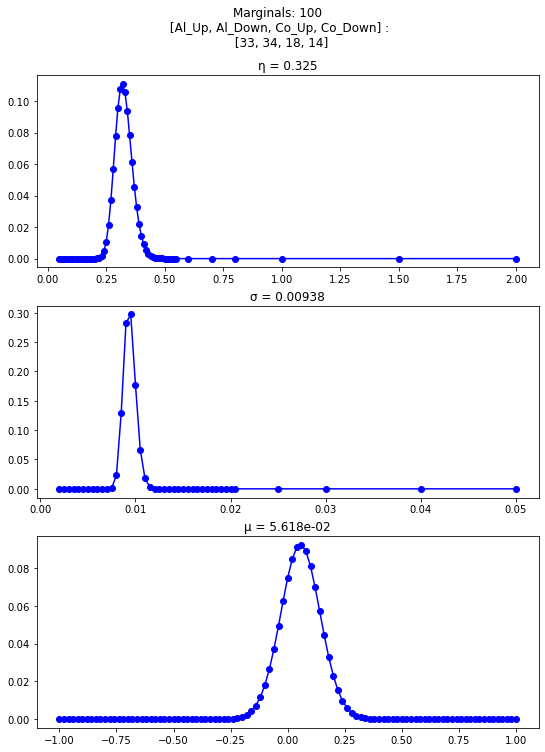

In [71]:
proc0.plot_marginals

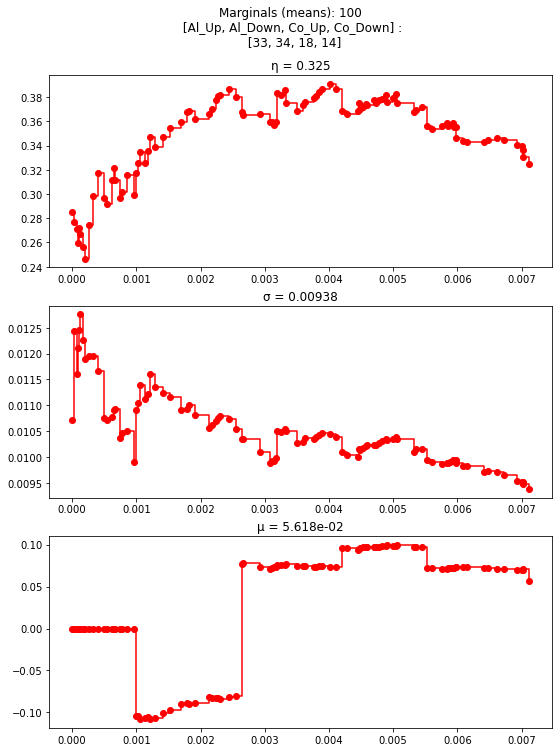

In [72]:
proc0.plot_marginals_means

In [73]:
for j in range(101, 501):
    proc0.update_with_counts(pxchg0list[j])
#     proc.update(*test_list[j])
    if j % 50 == 0:
        print(j)
#     if j % 100 == 0:
#         proc0.calc_update_freq()
#         proc0.update_freq()

150
200
250
300
350
400
450
500


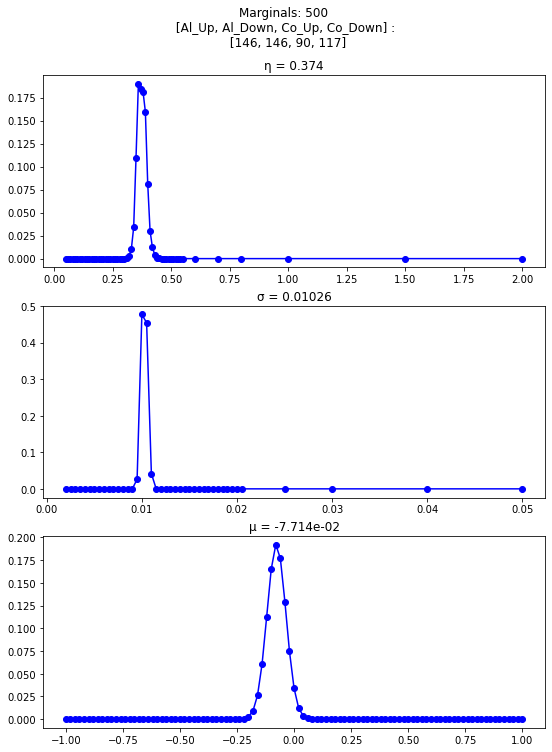

In [74]:
proc0.plot_marginals

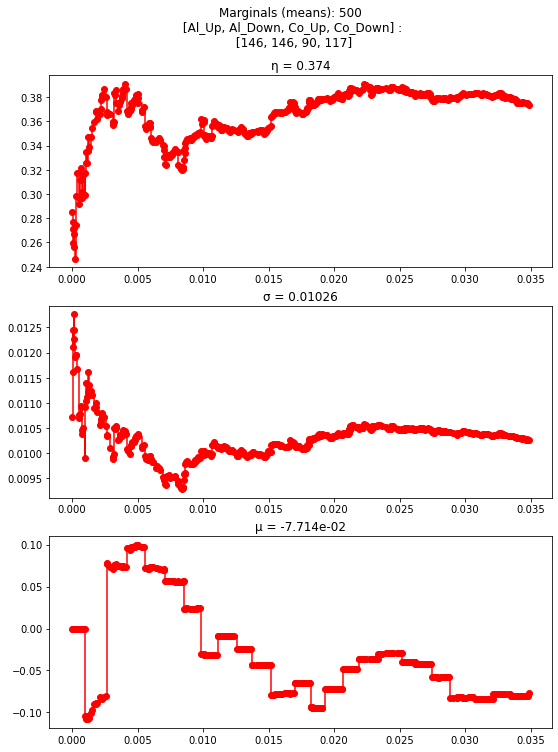

In [75]:
proc0.plot_marginals_means

In [76]:
for j in range(501, 1001):
    proc0.update_with_counts(pxchg0list[j])
#     proc.update(*test_list[j])
    if j % 100 == 0:
        print(j)

600
700
800
900
1000


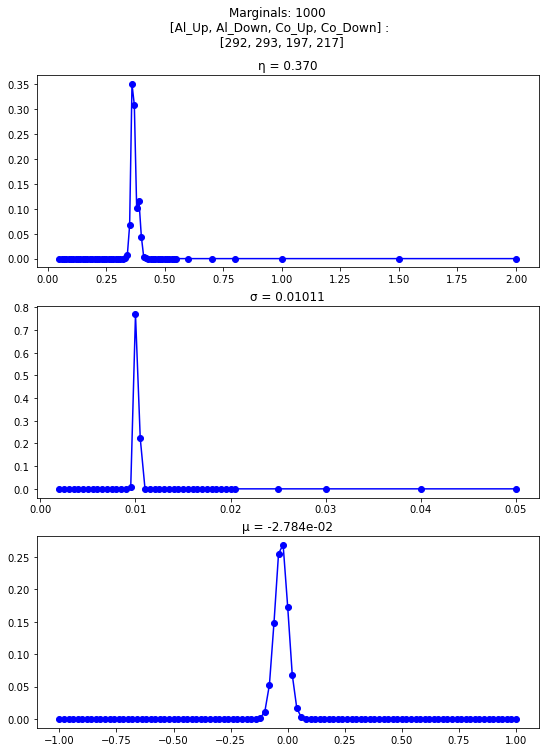

In [77]:
proc0.plot_marginals

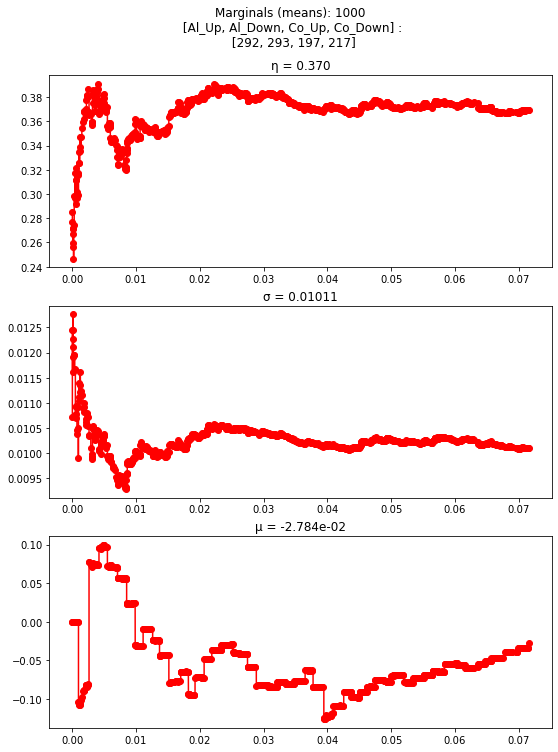

In [78]:
proc0.plot_marginals_means

In [79]:
for j in range(1001, len(pxchg0list)):
    proc0.update_with_counts(pxchg0list[j])
#     proc.update(*test_list[j])
    if j % 100 == 0:
        print(j)

1100
1200
1300
1400
1500
1600
1700
1800
1900
2000


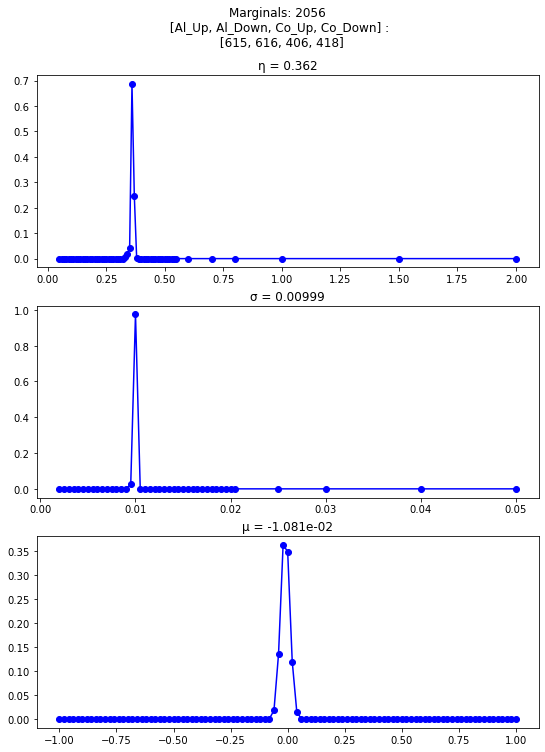

In [80]:
proc0.plot_marginals

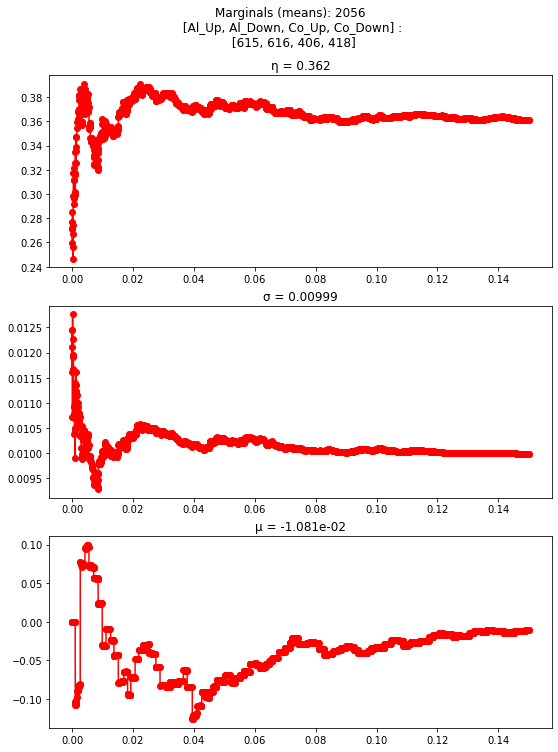

In [81]:
proc0.plot_marginals_means

In [85]:
proc0b = uz.Process(ηs, σs, μs, roll_window=50, update_freq=50)
proc0b.init_px(pxchg0list[0])
proc0b.init_px_chg(pxchg0list[1])
for j in range(2, 101):
    proc0b.update_with_counts(pxchg0list[j])
    if j % 20 == 0:
        print(j)

20
40
60
80
100


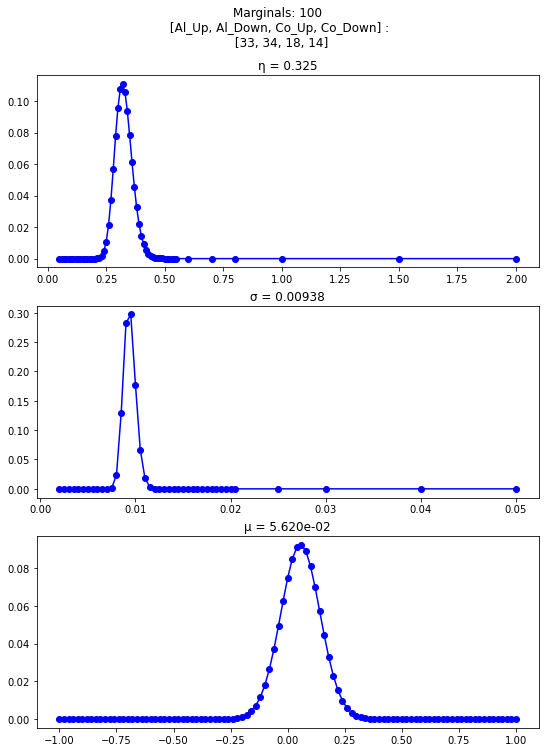

In [86]:
proc0b.plot_marginals

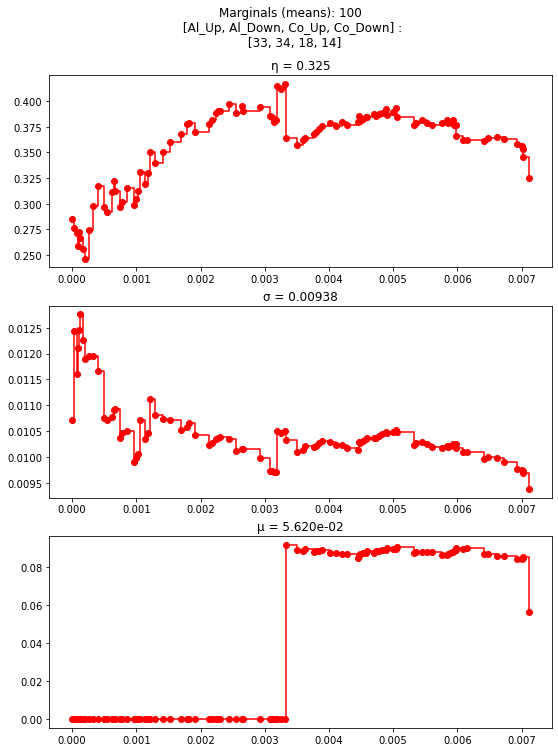

In [87]:
proc0b.plot_marginals_means

In [88]:
for j in range(101, 501):
    proc0b.update_with_counts(pxchg0list[j])
    if j % 50 == 0:
        print(j)

150
200
250
300
350
400
450
500


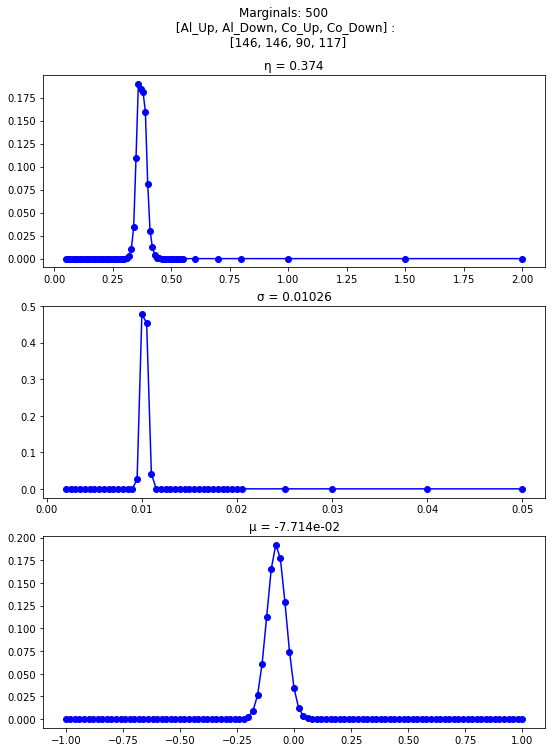

In [89]:
proc0b.plot_marginals

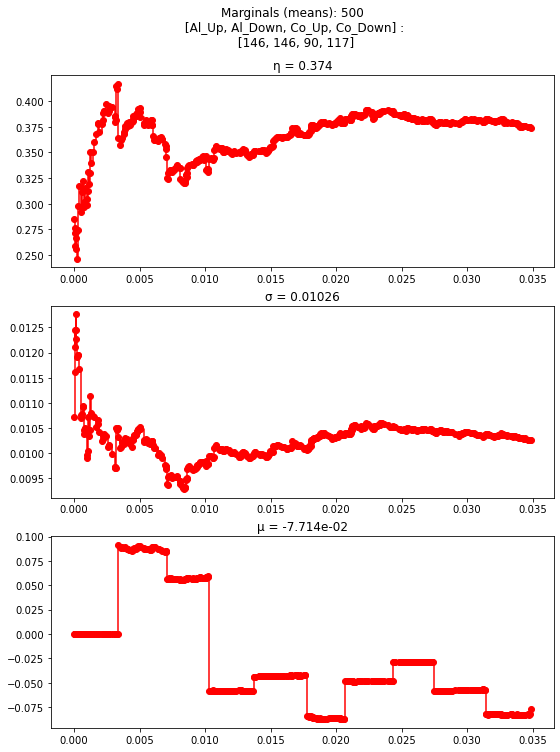

In [90]:
proc0b.plot_marginals_means

In [ ]:
for j in range(501, len(pxchg0list)):
    proc0b.update_with_counts(pxchg0list[j])
    if j % 50 == 0:
        print(j)

In [100]:
pxchg1list = df_to_list(pxchg1.loc[:0.15 * hours * 3600])
pxchg2list = df_to_list(pxchg2.loc[:0.15 * hours * 3600])
pxchg3list = df_to_list(pxchg3.loc[:0.15 * hours * 3600])
pxchg4list = df_to_list(pxchg4.loc[:0.15 * hours * 3600])
pxchg5list = df_to_list(pxchg5.loc[:0.15 * hours * 3600])
# pxchg6list = df_to_list(pxchg6.loc[:0.15 * hours * 3600])

In [119]:
pxchg7list = df_to_list(pxchg7.loc[:0.15 * hours * 3600])

In [101]:
len(pxchg0list)

2057

In [102]:
len(pxchg1list)

3511

In [103]:
len(pxchg2list)

2053

In [104]:
len(pxchg3list)

3644

In [105]:
len(pxchg4list)

2068

In [106]:
len(pxchg5list)

1235

In [120]:
len(pxchg7list)

1182

In [108]:
proc1 = uz.Process(ηs, σs, μs, roll_window=20, update_freq=20)
proc1.init_px(pxchg1list[0])
proc1.init_px_chg(pxchg1list[1])
for j in range(2, len(pxchg1list)):
    proc1.update_with_counts(pxchg1list[j])
    if j % 100 == 0:
        print(j)

100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500


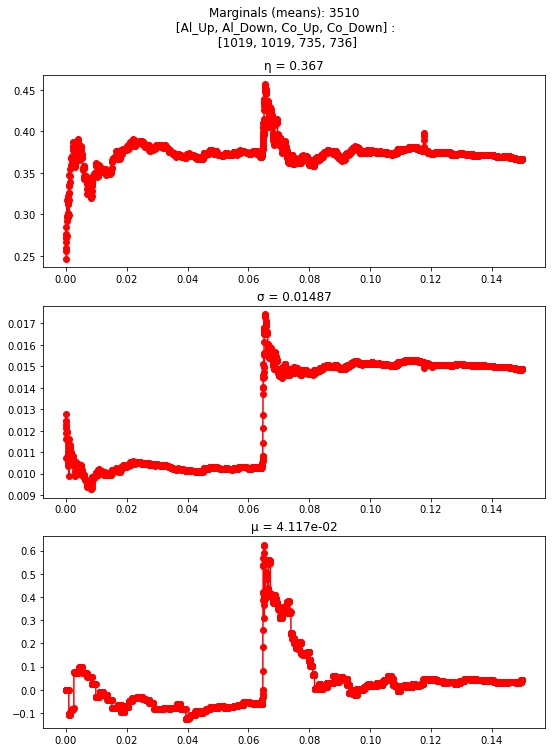

In [109]:
proc1.plot_marginals_means

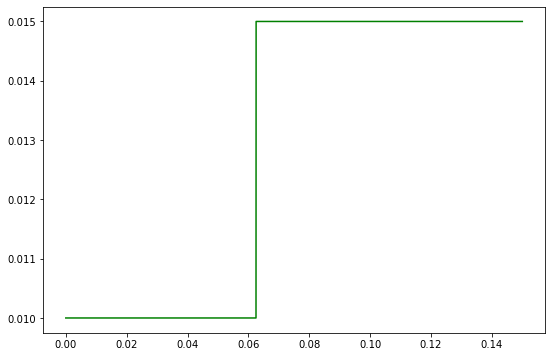

In [110]:
# pd.Series(v, index=tmrst[:-1]).loc[:0.15].plot(figsize=(9, 6), color='k');
pd.Series(v1, index=tmrst[:-1]).loc[:0.15].plot(figsize=(9, 6), color='g');
# pd.Series(v2, index=tmrst[:-1]).loc[:0.15].plot(figsize=(9, 6), color='b');

In [121]:
len(pxchg7list)

1182

In [122]:
proc7 = uz.Process(ηs, σs, μs, roll_window=20, update_freq=20)
proc7.init_px(pxchg7list[0])
proc7.init_px_chg(pxchg7list[1])
for j in range(2, len(pxchg7list)):
    proc7.update_with_counts(pxchg7list[j])
    if j % 100 == 0:
        print(j)

100
200
300
400
500
600
700
800
900
1000
1100


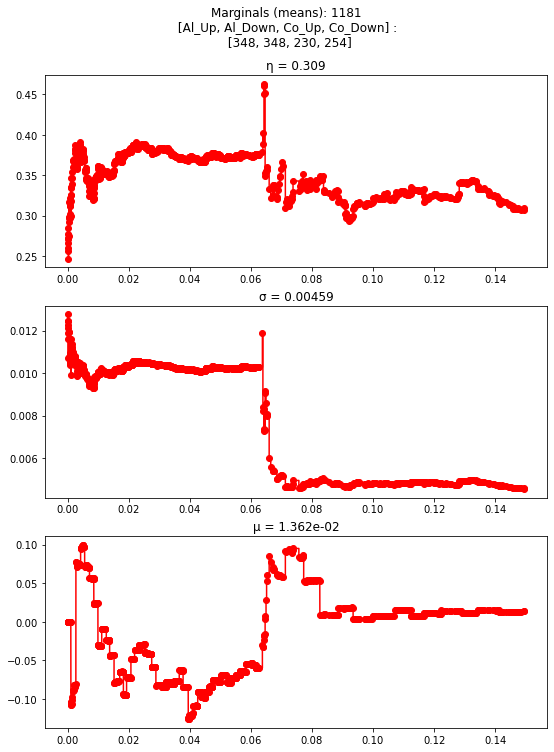

In [123]:
proc7.plot_marginals_means

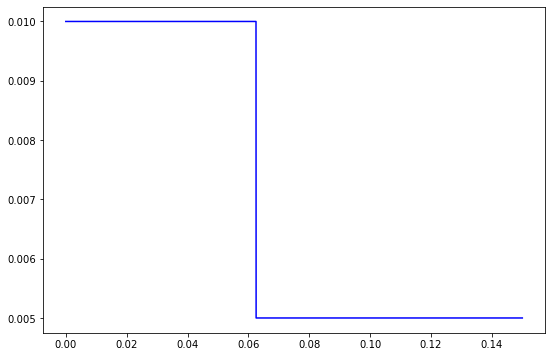

In [124]:
# pd.Series(v, index=tmrst[:-1]).loc[:0.15].plot(figsize=(9, 6), color='k');
# pd.Series(v1, index=tmrst[:-1]).loc[:0.15].plot(figsize=(9, 6), color='g');
pd.Series(v2, index=tmrst[:-1]).loc[:0.15].plot(figsize=(9, 6), color='b');

In [111]:
len(pxchg2list)

2053

In [143]:
proc2 = uz.Process(ηs, σs, μs, roll_window=20, update_freq=20)
proc2.init_px(pxchg2list[0])
proc2.init_px_chg(pxchg2list[1])
for j in range(2, len(pxchg2list)):
    proc2.update_with_counts(pxchg2list[j])
    if j % 100 == 0:
        print(j)

100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000


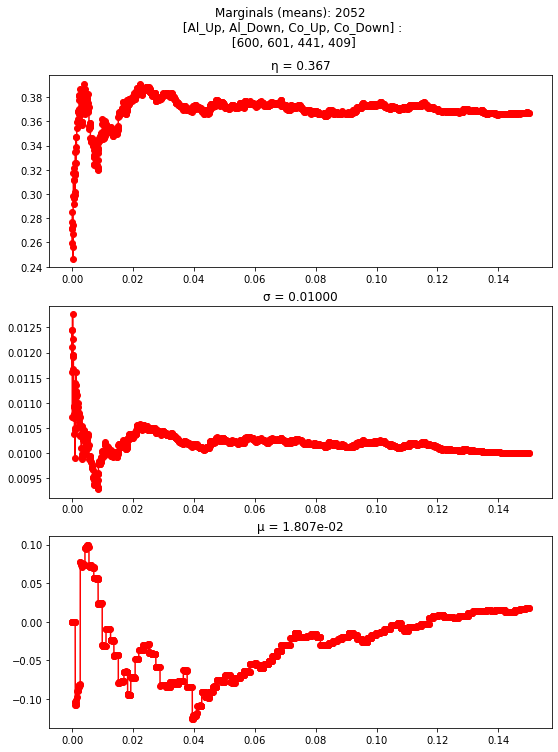

In [144]:
proc2.plot_marginals_means

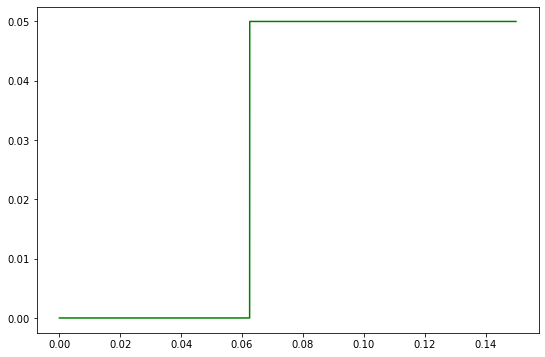

In [141]:
# pd.Series(mu, index=tmrst[:-1]).loc[:0.30].plot(figsize=(9, 6), color='k');
pd.Series(mu1, index=tmrst[:-1]).loc[:0.15].plot(figsize=(9, 6), color='g');
# pd.Series(mu2, index=tmrst[:-1]).loc[:0.30].plot(figsize=(9, 6), color='b');

In [125]:
len(pxchg3list)

3644

In [126]:
proc3 = uz.Process(ηs, σs, μs, roll_window=20, update_freq=20)
proc3.init_px(pxchg3list[0])
proc3.init_px_chg(pxchg3list[1])
for j in range(2, len(pxchg3list)):
    proc3.update_with_counts(pxchg3list[j])
    if j % 100 == 0:
        print(j)

100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600


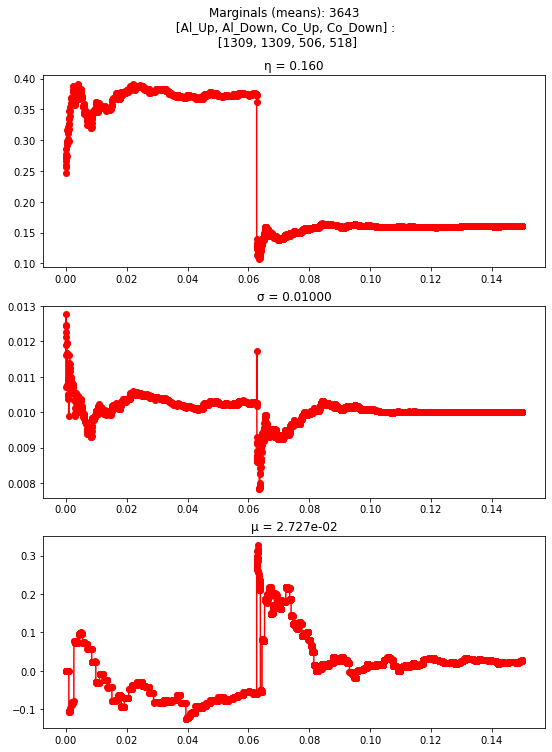

In [127]:
proc3.plot_marginals_means

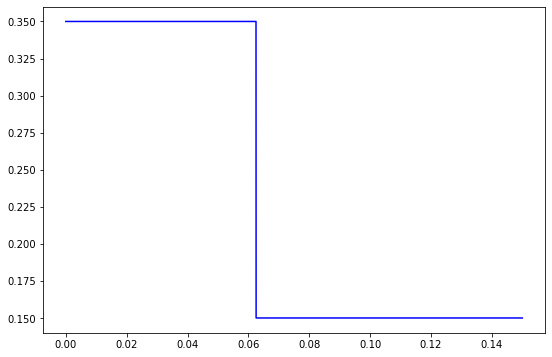

In [136]:
# pd.Series(eta, index=tmrst[:-1]).loc[:0.15].plot(figsize=(9, 6), color='k');
pd.Series(eta1, index=tmrst[:-1]).loc[:0.15].plot(figsize=(9, 6), color='b');

In [128]:
len(pxchg4list)

2068

In [137]:
proc4 = uz.Process(ηs, σs, μs, roll_window=20, update_freq=20)
proc4.init_px(pxchg4list[0])
proc4.init_px_chg(pxchg4list[1])
for j in range(2, len(pxchg4list)):
    proc4.update_with_counts(pxchg4list[j])
    if j % 100 == 0:
        print(j)

100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000


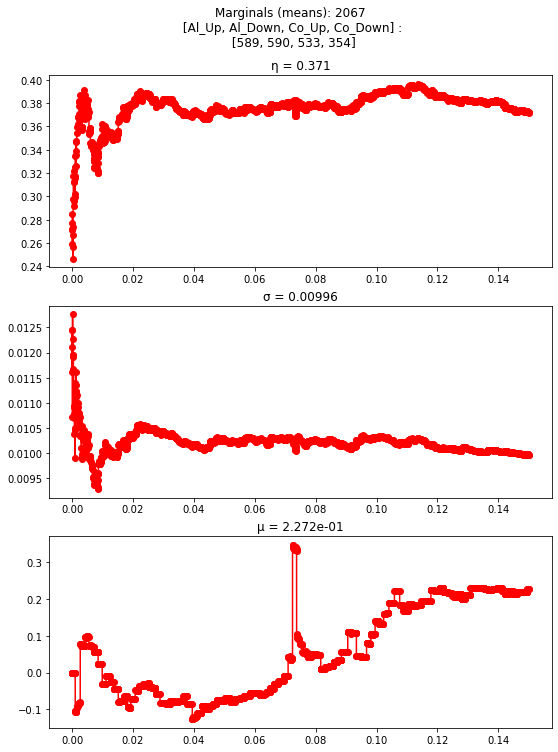

In [138]:
proc4.plot_marginals_means

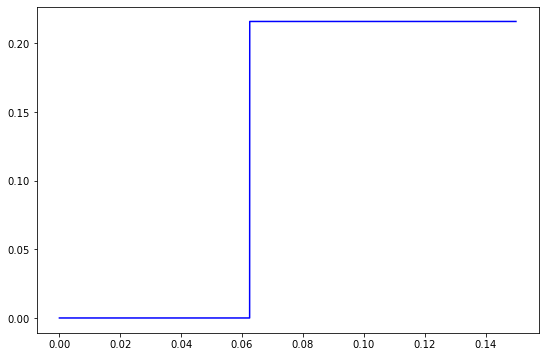

In [140]:
# pd.Series(mu, index=tmrst[:-1]).loc[:0.10].plot(figsize=(9, 6), color='k');
# pd.Series(mu1, index=tmrst[:-1]).loc[:0.10].plot(figsize=(9, 6), color='g');
pd.Series(mu2, index=tmrst[:-1]).loc[:0.15].plot(figsize=(9, 6), color='b');

In [132]:
len(pxchg5list)

1235

In [133]:
proc5 = uz.Process(ηs, σs, μs, roll_window=20, update_freq=20)
proc5.init_px(pxchg5list[0])
proc5.init_px_chg(pxchg5list[1])
for j in range(2, len(pxchg5list)):
    proc5.update_with_counts(pxchg5list[j])
    if j % 100 == 0:
        print(j)

100
200
300
400
500
600
700
800
900
1000
1100
1200


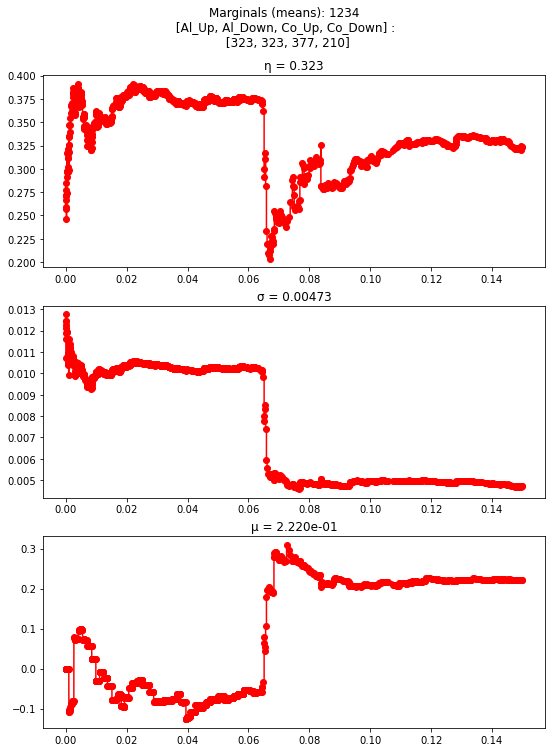

In [134]:
proc5.plot_marginals_means

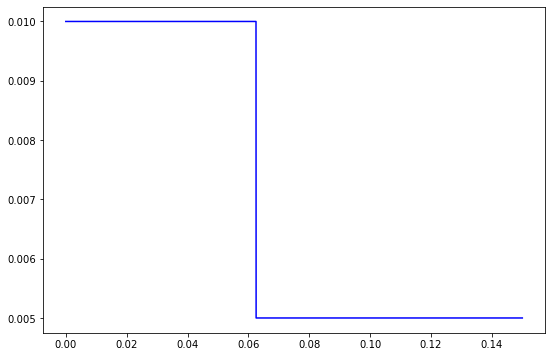

In [142]:
# pd.Series(v, index=tmrst[:-1]).loc[:0.10].plot(figsize=(9, 6), color='k');
# pd.Series(v1, index=tmrst[:-1]).loc[:0.10].plot(figsize=(9, 6), color='g');
pd.Series(v2, index=tmrst[:-1]).loc[:0.15].plot(figsize=(9, 6), color='b');

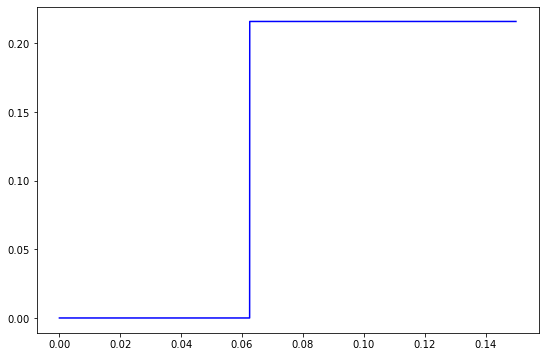

In [140]:
# pd.Series(mu, index=tmrst[:-1]).loc[:0.10].plot(figsize=(9, 6), color='k');
# pd.Series(mu1, index=tmrst[:-1]).loc[:0.10].plot(figsize=(9, 6), color='g');
pd.Series(mu2, index=tmrst[:-1]).loc[:0.15].plot(figsize=(9, 6), color='b');

In [37]:
# uz.qq_plots(pxchg0, α, η, σ, μ, hours)

H            0.304066
σXe          0.009885
η            0.307937
σ            0.009931
μ           -0.005047
Σdists       0.020537
f_Al_Up      0.310920
w_Al_Up      0.309426
d_Al_Up      0.021141
f_Co_Up      0.187488
w_Co_Up      0.188995
d_Co_Up      0.012350
f_Al_Down    0.310920
w_Al_Down    0.309426
d_Al_Down    0.010824
f_Co_Down    0.190672
w_Co_Down    0.192152
d_Co_Down    0.027774
dtype: float64

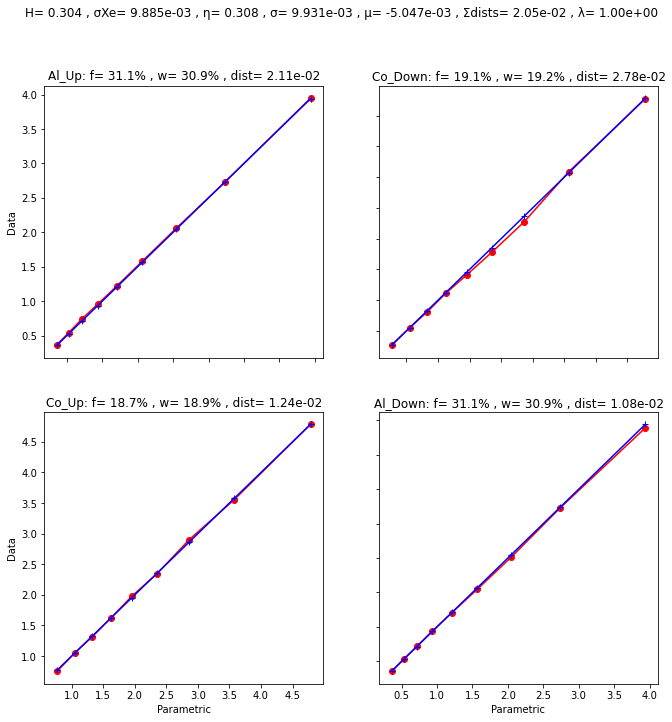

In [36]:
uz.fit_trio(pxchg0, α, hours, show_charts=True)

In [35]:
# pxchg0.head()

In [36]:
# pxchg0.describe()

In [38]:
min_window = 15
min_step = 1
min_range = range(min_window, hours * 60 + min_step, min_step)

In [39]:
λ0 = 1

In [40]:
def stats_window(data, α=α, hours=hours, λ=λ0, window_min=min_window, time_step_min=min_step):
    min_range = range(min_window, hours * 60 + min_step, min_step)
    path_roll_min = [uz.fit_trio(data.loc[((m - min_window) * 60):(m * 60)], α, hours, λ) for m in min_range]
    df_stats_roll = pd.concat(path_roll_min, axis=1).transpose()
    df_stats_roll.index = np.array(min_range) / 60
    path_cum_min = [uz.fit_trio(data.loc[:(m * 60)], α, hours, λ) for m in min_range]
    df_stats_cum = pd.concat(path_cum_min, axis=1).transpose()
    df_stats_cum.index = np.array(min_range) / 60
    return [df_stats_roll, df_stats_cum]

In [56]:
def plot_stats(data_roll, data_cum, eta_ts, vol_ts, mu_ts, tmrst=tmrst, hours=hours, window_min=min_window):
    fig, axs = plt.subplots(4, 2, figsize=(18, 24))
    fig.suptitle('Window = ' + str(window_min) + 'min, t = ', y=0.90)
    
    data_index = data_roll.index
    
    eta_ts_ds = pd.Series(eta_ts, index=tmrst[:-1] * hours).loc[min_window / 60:]
    eta_plot = pd.Series([np.mean(eta_ts_ds.loc[t - 1e-5:t + 1e-5].values) for t in data_index],
                        index=data_index)
    vol_ts_ds = pd.Series(vol_ts, index=tmrst[:-1] * hours).loc[min_window / 60:]
    vol_plot = pd.Series([np.mean(vol_ts_ds.loc[t - 1e-5:t + 1e-5].values) for t in data_index],
                        index=data_index)
    mu_ts_ds = pd.Series(mu_ts, index=tmrst[:-1] * hours).loc[min_window / 60:]
    mu_plot = pd.Series([np.mean(mu_ts_ds.loc[t - 1e-5:t + 1e-5].values) for t in data_index],
                        index=data_index)
    
    axs[0, 0].plot(data_roll[['η', 'H']])
    axs[0, 0].plot(eta_plot, color='k')
    axs[0, 0].legend(['η', 'H'])
    axs[0, 0].set_title('η and H - Rolling')
    axs[0, 1].plot(data_cum[['η', 'H']])
    axs[0, 1].plot(eta_plot, color='k')
    axs[0, 1].legend(['η', 'H'])
    axs[0, 1].set_title('η and H - Cumulative')
    
    axs[1, 0].plot(data_roll[['σ', 'σXe']])
    axs[1, 0].plot(vol_plot, color='k')
    axs[1, 0].set_title('σ and σXe - Rolling')
    axs[1, 0].legend(['σ', 'σXe'])
    axs[1, 1].plot(data_cum[['σ', 'σXe']])
    axs[1, 1].plot(vol_plot, color='k')
    axs[1, 1].legend(['σ', 'σXe'])
    axs[1, 1].set_title('σ and σXe - Cumulative')
    
    axs[2, 0].plot(data_roll[['μ']])
    axs[2, 0].plot(mu_plot, color='k')
    axs[2, 0].legend(['μ'])
    axs[2, 0].set_title('μ - Rolling')
    axs[2, 1].plot(data_cum[['μ']])
    axs[2, 1].plot(mu_plot, color='k')
    axs[2, 1].legend(['μ'])
    axs[2, 1].set_title('μ - Cumulative')
    
    axs[3, 0].plot(data_roll[['f_Al_Up', 'f_Co_Up', 'f_Al_Down', 'f_Co_Down']])
    axs[3, 0].plot(eta_plot, color='k')
    axs[3, 0].legend(['f_Al_Up', 'f_Co_Up', 'f_Al_Down', 'f_Co_Down'])
    axs[3, 0].set_title('Frequencies - Rolling')
    axs[3, 1].plot(data_cum[['f_Al_Up', 'f_Co_Up', 'f_Al_Down', 'f_Co_Down']])
    axs[3, 1].plot(eta_plot, color='k')
    axs[3, 1].legend(['f_Al_Up', 'f_Co_Up', 'f_Al_Down', 'f_Co_Down'])
    axs[3, 1].set_title('Frequencies - Cumulative')

In [42]:
start = timeit.default_timer()
df_stats_roll0, df_stats_cum0 = stats_window(pxchg0)
stop = timeit.default_timer()
print('Time Spent: ', round(stop - start), ' seconds')

Time Spent:  64  seconds


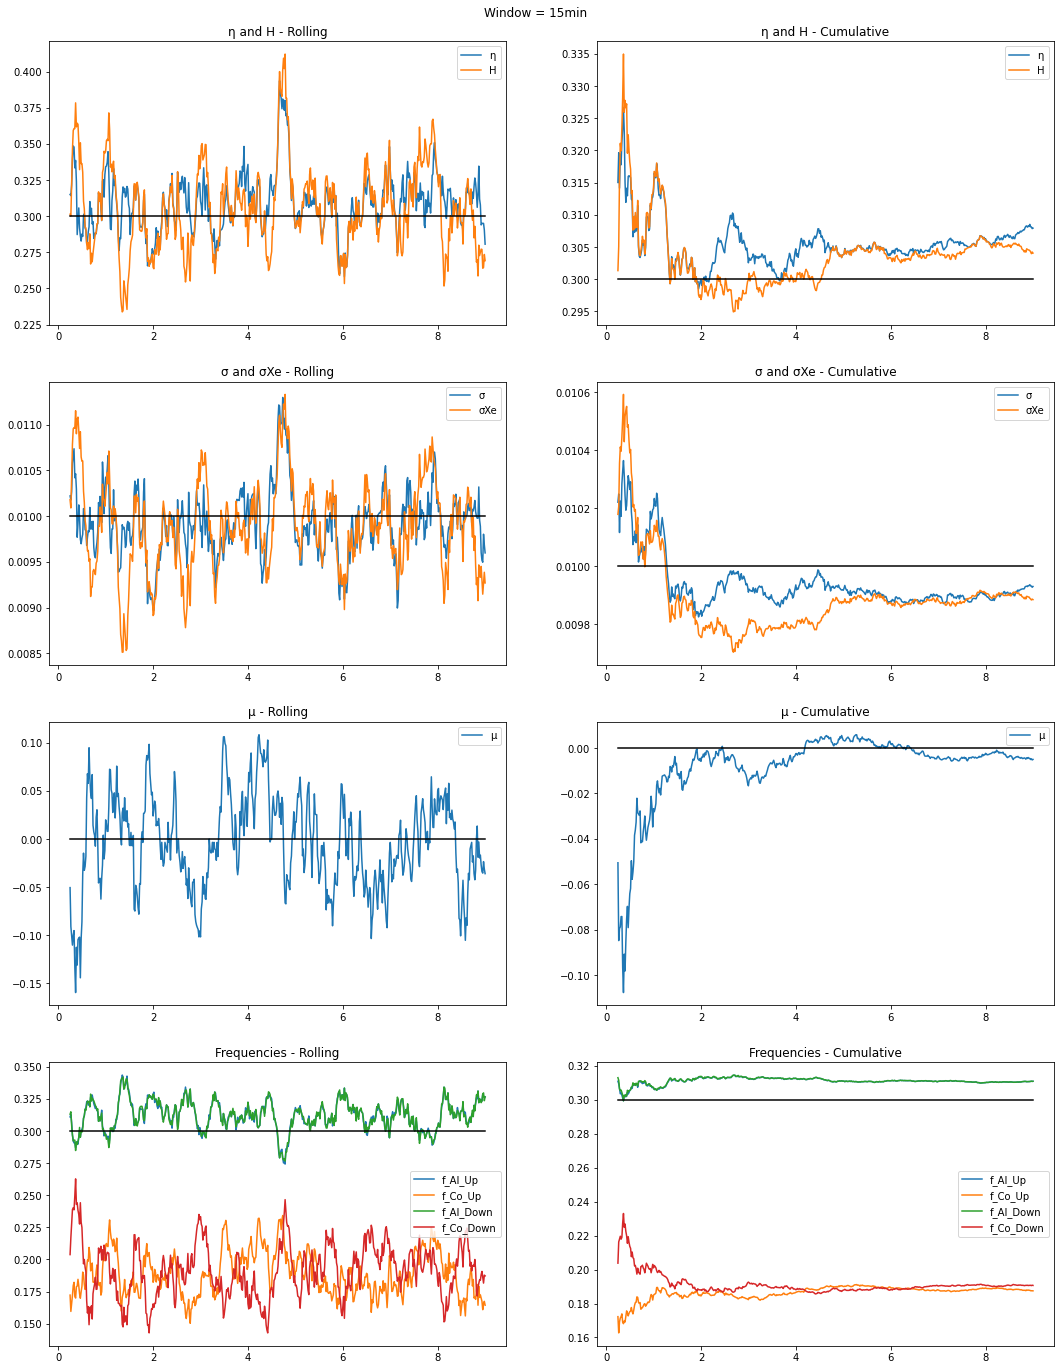

In [57]:
plot_stats(df_stats_roll0, df_stats_cum0, eta, v, mu)

In [44]:
start = timeit.default_timer()
df_stats_roll1, df_stats_cum1 = stats_window(pxchg1)
stop = timeit.default_timer()
print('Time Spent: ', round(stop - start), ' seconds')

Time Spent:  92  seconds


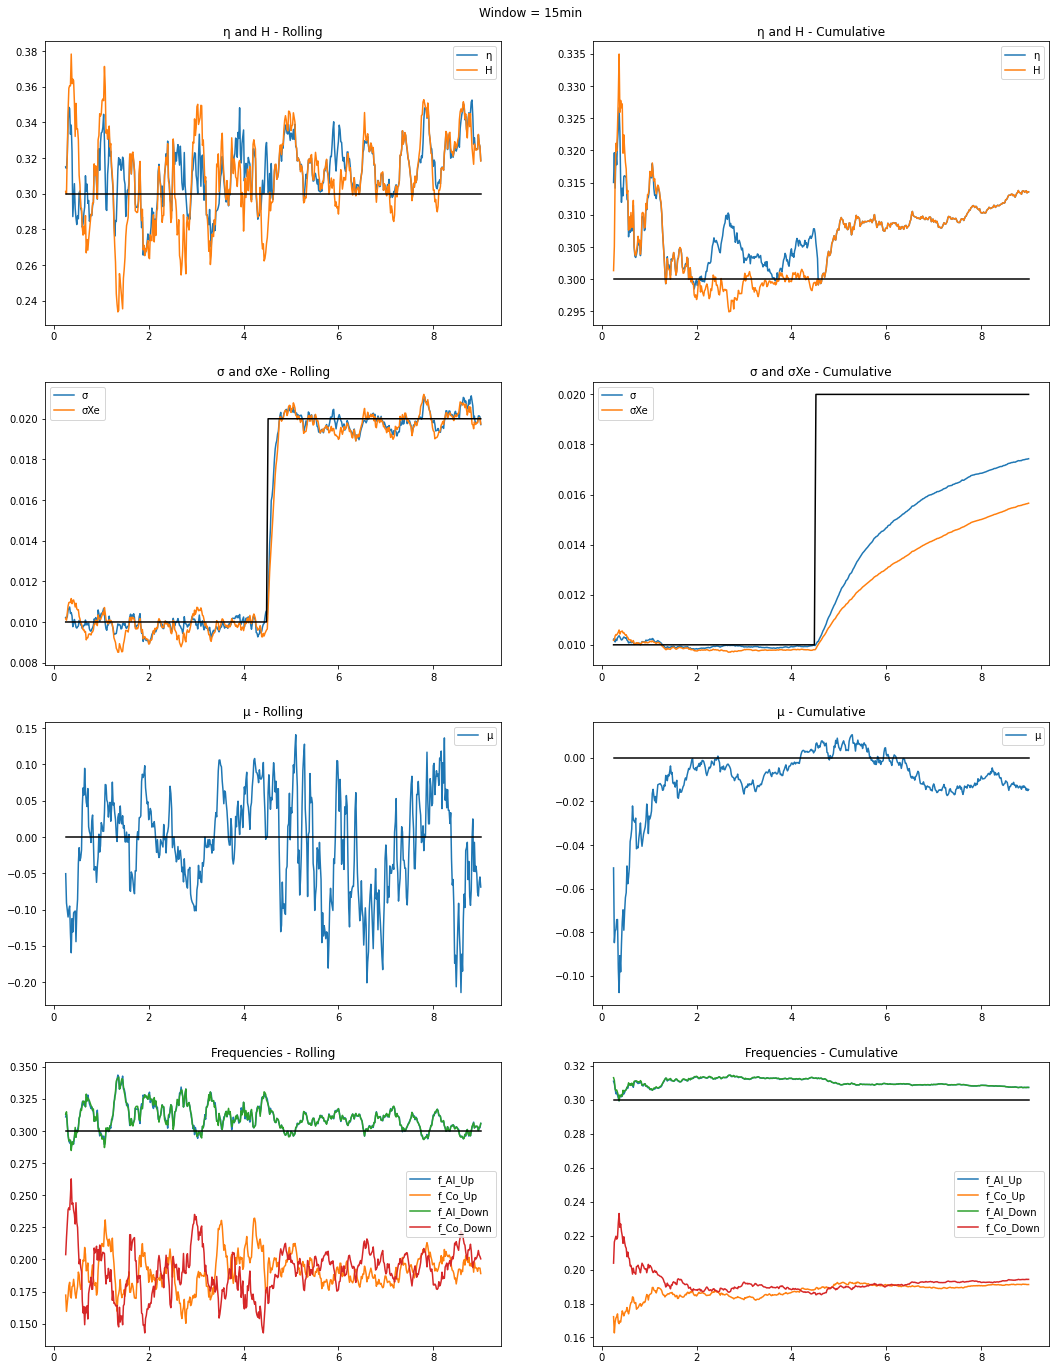

In [58]:
plot_stats(df_stats_roll1, df_stats_cum1, eta, v1, mu)

In [46]:
start = timeit.default_timer()
df_stats_roll2, df_stats_cum2 = stats_window(pxchg2)
stop = timeit.default_timer()
print('Time Spent: ', round(stop - start), ' seconds')

Time Spent:  67  seconds


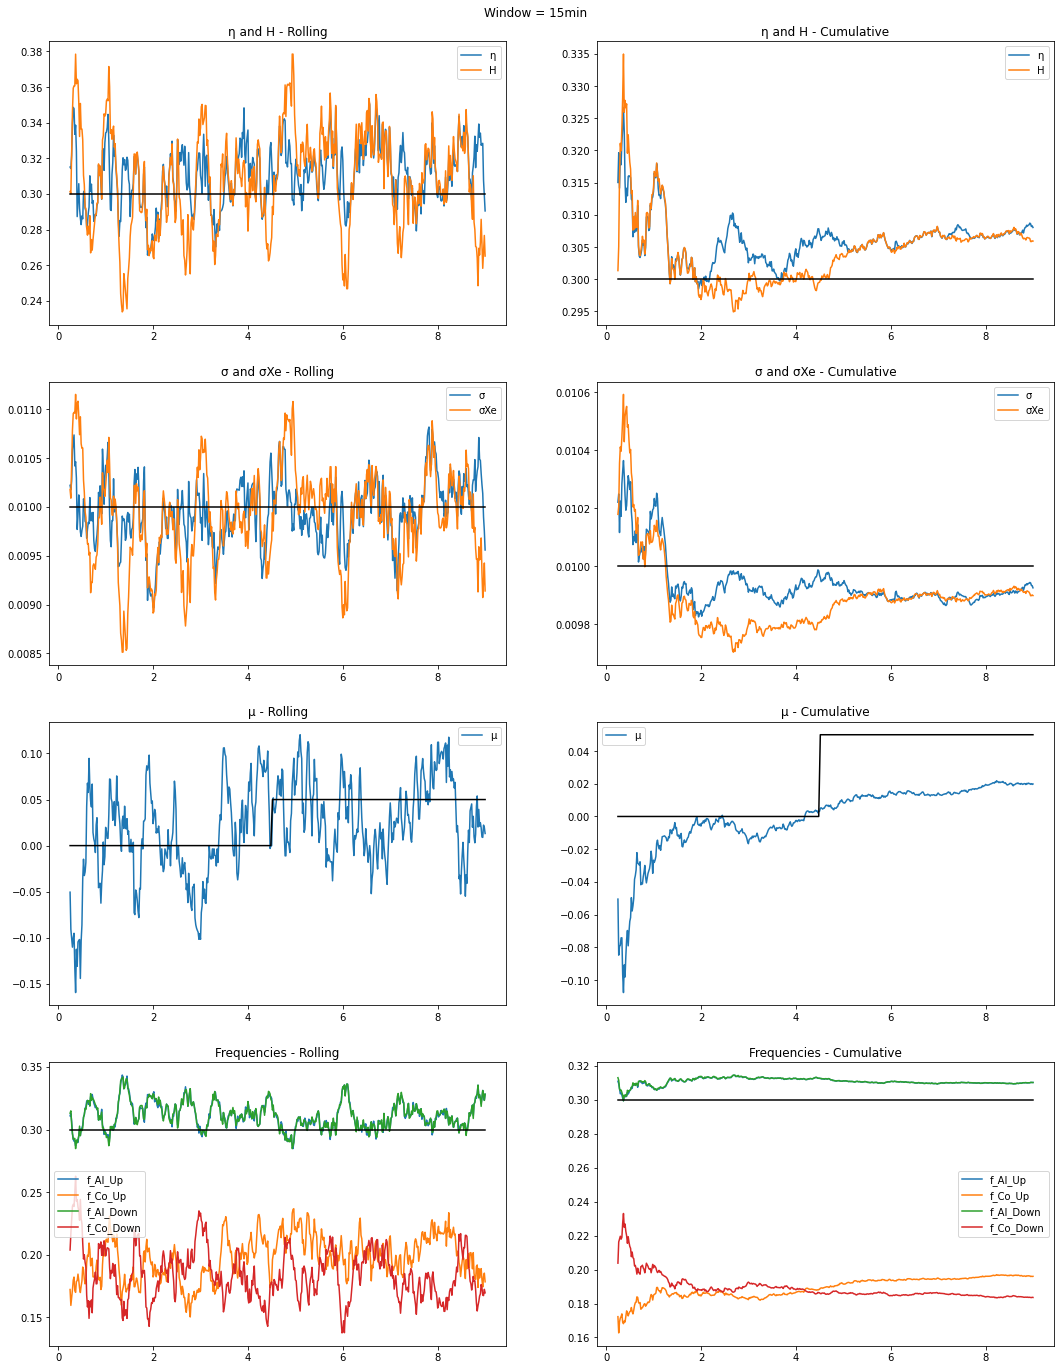

In [59]:
plot_stats(df_stats_roll2, df_stats_cum2, eta, v, mu1)

In [48]:
start = timeit.default_timer()
df_stats_roll3, df_stats_cum3 = stats_window(pxchg3)
stop = timeit.default_timer()
print('Time Spent: ', round(stop - start), ' seconds')

Time Spent:  90  seconds


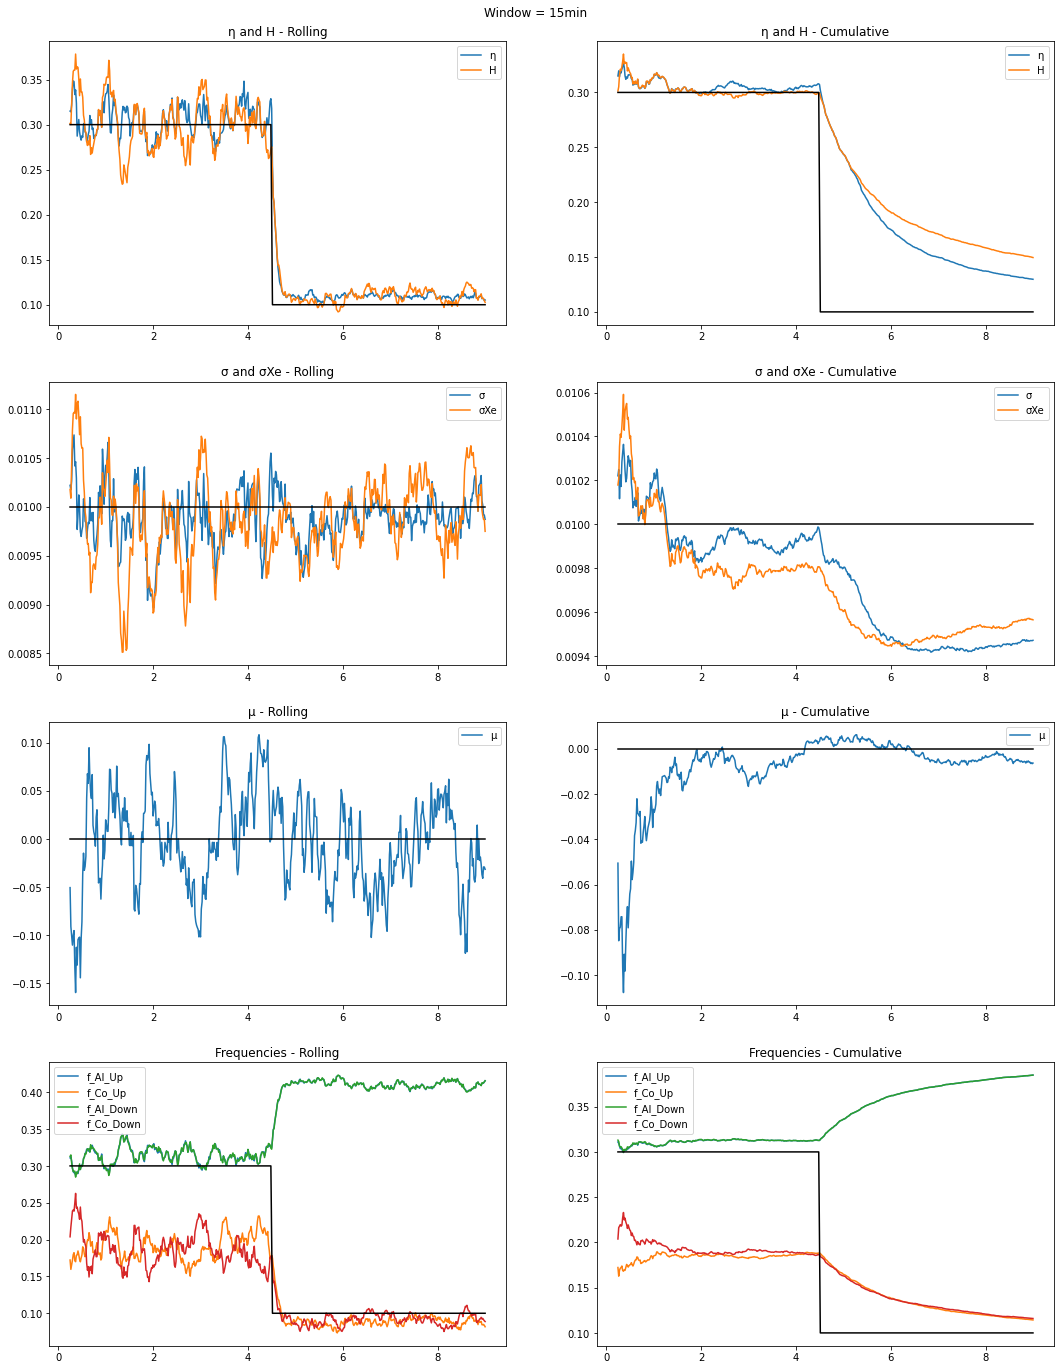

In [60]:
plot_stats(df_stats_roll3, df_stats_cum3, eta1, v, mu)

In [50]:
start = timeit.default_timer()
df_stats_roll4, df_stats_cum4 = stats_window(pxchg4)
stop = timeit.default_timer()
print('Time Spent: ', round(stop - start), ' seconds')

Time Spent:  75  seconds


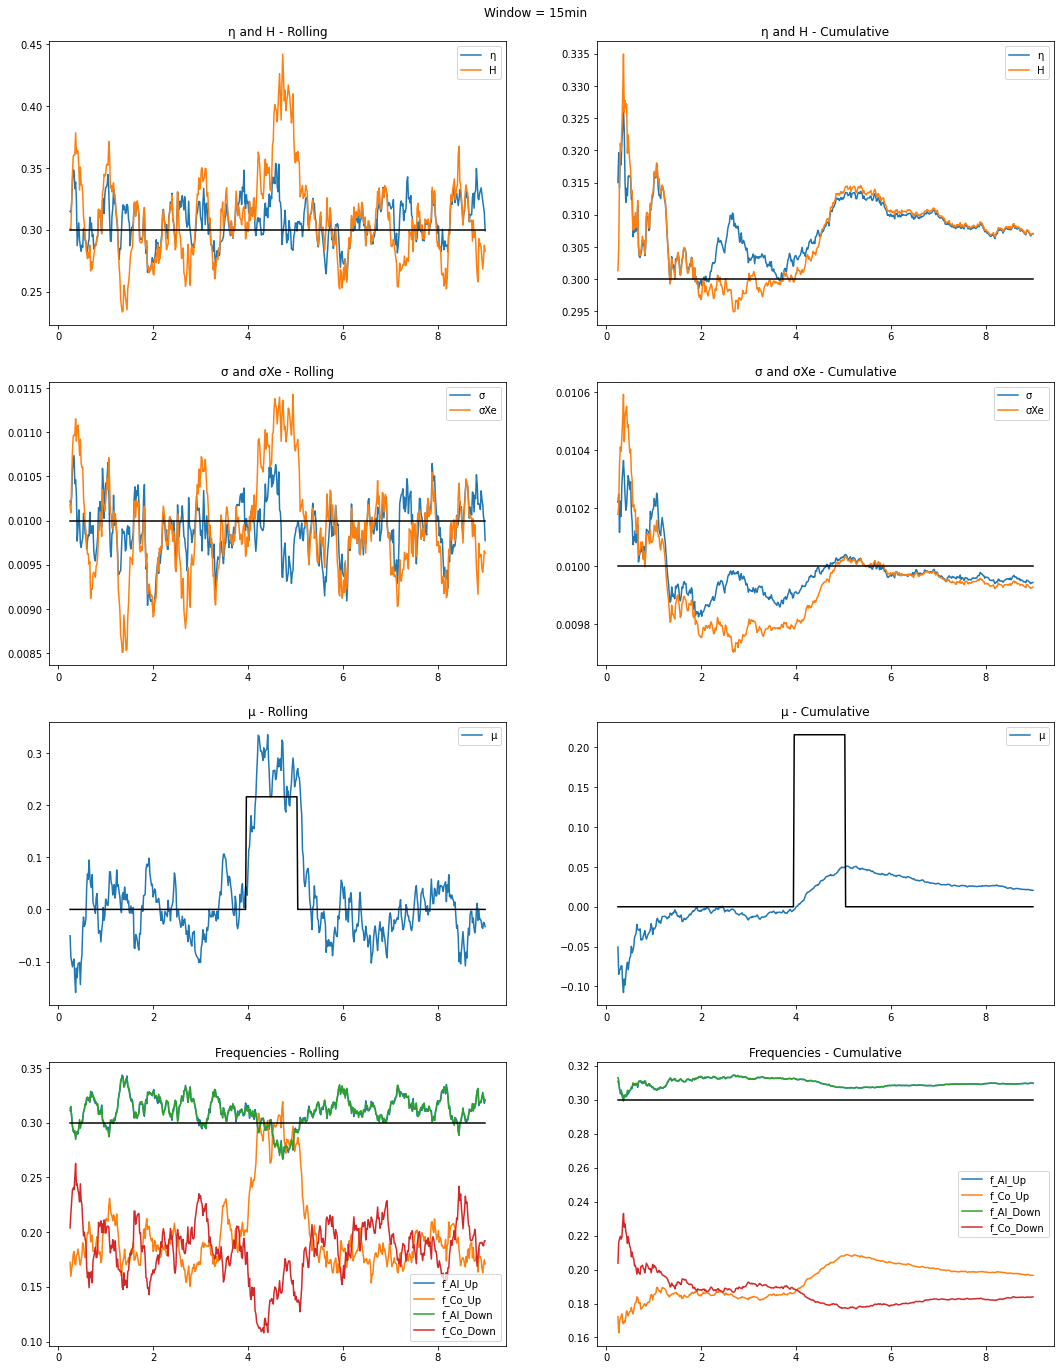

In [61]:
plot_stats(df_stats_roll4, df_stats_cum4, eta, v, mu2)

In [52]:
start = timeit.default_timer()
df_stats_roll5, df_stats_cum5 = stats_window(pxchg5)
stop = timeit.default_timer()
print('Time Spent: ', round(stop - start), ' seconds')

Time Spent:  119  seconds


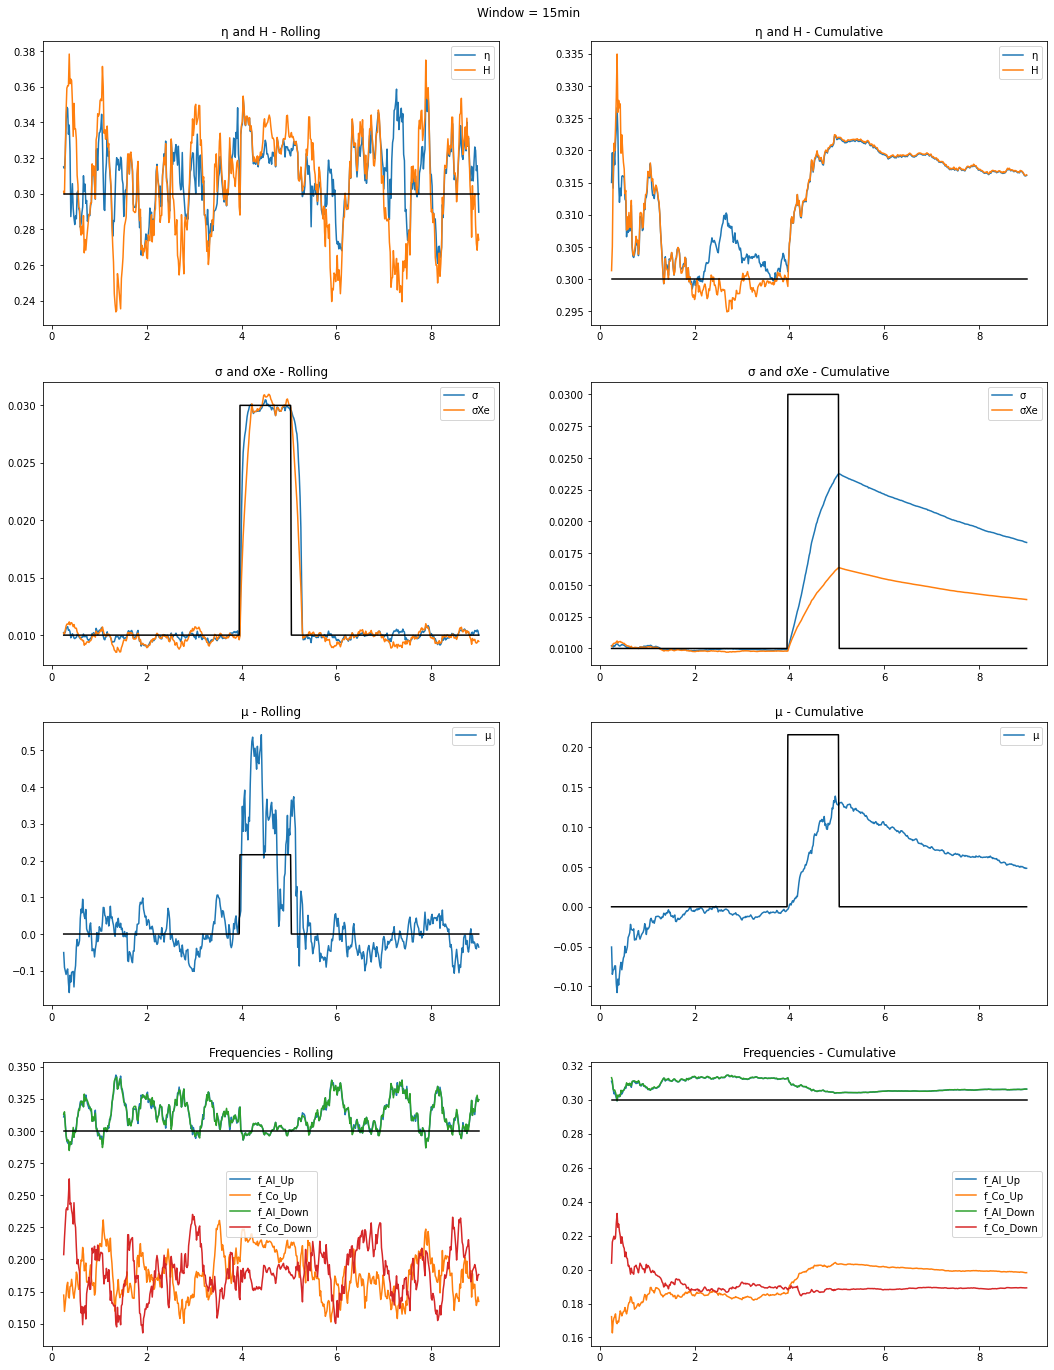

In [62]:
plot_stats(df_stats_roll5, df_stats_cum5, eta, v2, mu2)

In [ ]:

algo_tr = rpt.Pelt(model='l2', min_size=100).fit(pxchg2['dtj'].dropna().values)
my_bkps_tr = algo_tr.predict(pen=3)

In [ ]:

rpt.display(pxchg2['dtj'].dropna().values, my_bkps_tr)


